In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_curve, roc_auc_score
import os
import math

# Training and validation data

In [ ]:
df_val = pd.read_csv(f'../260330_af3_benchmark/Supplementary_Tables/Supplementary_Table_1.csv')[['Epitope', 'TRAV', 'TRAJ', 'cdr3_TRA', 'TRBV', 'TRBJ', 'cdr3_TRB', 'dataset_source', 'Label']]
df_val = df_val.rename(columns={'Epitope' : 'model'})
df_val = df_val[df_val['dataset_source'].isin(['Public TCRs with undetermined specificities', 'Public Paired Data'])]

topir = 'TCR_motif_atlas'

final_epitopes = []
for model, val_group in df_val.groupby('model'):
    if model not in ["A0201_LLWNGPMAV", "A0201_GILGFVFTL"]:
        continue
    if not (model.startswith('A') or model.startswith('B')):
        continue
    if not len(val_group):
        continue
    print(model)
    val_group.to_csv(f'{topir}/{model}/validation.csv', index=False)
    final_epitopes.append(model)

with open(f'{topir}/epitopes.txt', 'w') as f:
    f.write('\n'.join(final_epitopes))

print(f'{len(final_epitopes)} epitopes written to epitopes.txt')

A0201_GILGFVFTL
A0201_LLWNGPMAV
2 epitopes written to epitopes.txt


# ESMfold2 scores

step0 A0201_GILGFVFTL 0.7 2
step1 A0201_GILGFVFTL 0.7 24
step2 A0201_GILGFVFTL 0.7 31
step0 A0201_LLWNGPMAV 0.7 0
step1 A0201_LLWNGPMAV 0.7 9
step2 A0201_LLWNGPMAV 0.7 1


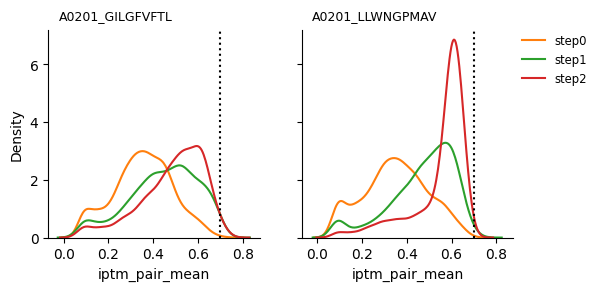

In [4]:
fig, axes = plt.subplots(1,2, figsize=(3*2,2.7), sharex=True, sharey=True)

steps = ['step0', 'step1', 'step2']
peptides = ['A0201_GILGFVFTL', 'A0201_LLWNGPMAV']

# default seaborn/matplotlib palette, skipping the first color (blue)
colors = sns.color_palette()[1:len(steps)+1]


for cnt, peptide in enumerate(peptides):
    ax = axes[cnt]

    for step, color in zip(steps, colors):
        df1 = pd.read_csv(f'TCR_motif_atlas/{peptide}/{step}/output_alpha.csv')[['ID', 'iptm_pair_mean']]
        df2 = pd.read_csv(f'TCR_motif_atlas/{peptide}/{step}/output_beta.csv')[['ID', 'iptm_pair_mean']]
        df = pd.concat([df1, df2])
        sns.kdeplot(df, x='iptm_pair_mean', ax=ax, label=step, color=color)

        #df = pd.read_csv(f'TCR_motif_atlas/{peptide}/{step}/output-beta.csv')[['ID', 'iptm_pair_mean']]
        #sns.kdeplot(df, x='AF3_iptm_pair_mean', ax=ax, label=f'{step} (no prior)', color=color, linestyle=':')
        

        print(step, peptide, 0.7, len(df[df['iptm_pair_mean']>0.7]))

    ax.axvline(x=0.7, color='black', linestyle=':')
    sns.despine()
    ax.text(0.05, 1.05, f'{peptide}', transform=ax.transAxes, fontsize=9)

axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize='small', frameon=False)

    

step0 A0201_GILGFVFTL 0.7 2
step1 A0201_GILGFVFTL 0.7 18
step0 A0201_LLWNGPMAV 0.7 0
step1 A0201_LLWNGPMAV 0.7 5


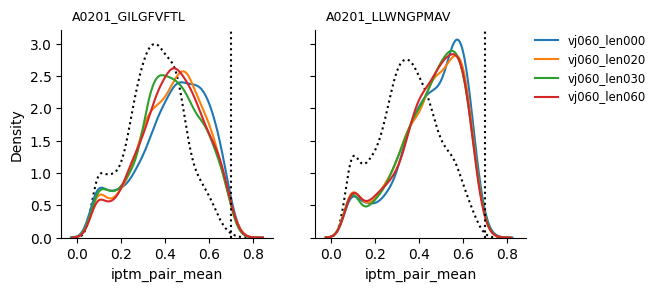

In [6]:
fig, axes = plt.subplots(1,2, figsize=(3*2,2.7), sharex=True, sharey=True)

steps = ['step0', 'step1']
peptides = ['A0201_GILGFVFTL', 'A0201_LLWNGPMAV']
params = ['vj060_len000', 'vj060_len020', 'vj060_len030', 'vj060_len060']

# default seaborn/matplotlib palette, skipping the first color (blue)
colors = sns.color_palette()[1:len(steps)+1]


for cnt, peptide in enumerate(peptides):
    ax = axes[cnt]

    for step, color in zip(steps, colors):
        if step == 'step0':
            df1 = pd.read_csv(f'benchmark_LEN/vj060_len000/{peptide}/{step}/output_alpha.csv')[['ID', 'iptm_pair_mean']]
            df2 = pd.read_csv(f'benchmark_LEN/vj060_len000/{peptide}/{step}/output_beta.csv')[['ID', 'iptm_pair_mean']]
            df = pd.concat([df1, df2])
            sns.kdeplot(df, x='iptm_pair_mean', ax=ax, color='black', linestyle=':')
        else:
            for p in params:
                df1 = pd.read_csv(f'benchmark_LEN/{p}/{peptide}/{step}/output_alpha.csv')[['ID', 'iptm_pair_mean']]
                df2 = pd.read_csv(f'benchmark_LEN/{p}/{peptide}/{step}/output_beta.csv')[['ID', 'iptm_pair_mean']]
                df = pd.concat([df1, df2])
                sns.kdeplot(df, x='iptm_pair_mean', ax=ax, label=p)


        print(step, peptide, 0.7, len(df[df['iptm_pair_mean']>0.7]))

    ax.axvline(x=0.7, color='black', linestyle=':')
    sns.despine()
    ax.text(0.05, 1.05, f'{peptide}', transform=ax.transAxes, fontsize=9)

axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize='small', frameon=False)

    

step0 A0201_GILGFVFTL 0.7 2
step2 A0201_GILGFVFTL 0.7 39
step0 A0201_LLWNGPMAV 0.7 0
step2 A0201_LLWNGPMAV 0.7 8


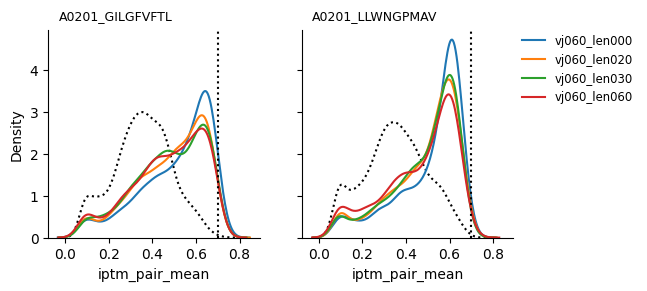

In [2]:
fig, axes = plt.subplots(1,2, figsize=(3*2,2.7), sharex=True, sharey=True)

steps = ['step0', 'step2']
peptides = ['A0201_GILGFVFTL', 'A0201_LLWNGPMAV']
params = ['vj060_len000', 'vj060_len020', 'vj060_len030', 'vj060_len060']

# default seaborn/matplotlib palette, skipping the first color (blue)
colors = sns.color_palette()[1:len(steps)+1]


for cnt, peptide in enumerate(peptides):
    ax = axes[cnt]

    for step, color in zip(steps, colors):
        if step == 'step0':
            df1 = pd.read_csv(f'benchmark_LEN/vj060_len000/{peptide}/{step}/output_alpha.csv')[['ID', 'iptm_pair_mean']]
            df2 = pd.read_csv(f'benchmark_LEN/vj060_len000/{peptide}/{step}/output_beta.csv')[['ID', 'iptm_pair_mean']]
            df = pd.concat([df1, df2])
            sns.kdeplot(df, x='iptm_pair_mean', ax=ax, color='black', linestyle=':')
        else:
            for p in params:
                df1 = pd.read_csv(f'benchmark_LEN/{p}/{peptide}/{step}/output_alpha.csv')[['ID', 'iptm_pair_mean']]
                df2 = pd.read_csv(f'benchmark_LEN/{p}/{peptide}/{step}/output_beta.csv')[['ID', 'iptm_pair_mean']]
                df = pd.concat([df1, df2])
                sns.kdeplot(df, x='iptm_pair_mean', ax=ax, label=p)


        print(step, peptide, 0.7, len(df[df['iptm_pair_mean']>0.7]))

    ax.axvline(x=0.7, color='black', linestyle=':')
    sns.despine()
    ax.text(0.05, 1.05, f'{peptide}', transform=ax.transAxes, fontsize=9)

axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize='small', frameon=False)

    

2 A0201_GILGFVFTL 0.65 60
2 A0201_GILGFVFTL 0.65 584
2 A0201_LLWNGPMAV 0.65 118
2 A0201_LLWNGPMAV 0.65 156


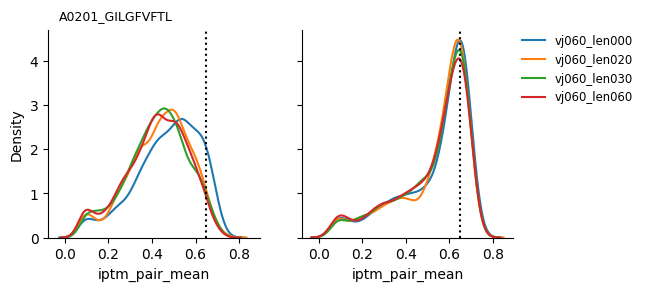

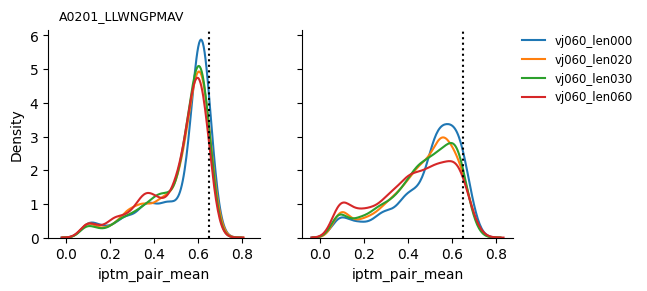

In [17]:
peptides = ['A0201_GILGFVFTL', 'A0201_LLWNGPMAV']
params = ['vj060_len000', 'vj060_len020', 'vj060_len030', 'vj060_len060']
chains = ['alpha', 'beta']

# default seaborn/matplotlib palette, skipping the first color (blue)
colors = sns.color_palette()[1:len(steps)+1]


for cnt, peptide in enumerate(peptides):
    fig, axes = plt.subplots(1,2, figsize=(3*2,2.7), sharex=True, sharey=True)
    
    for cnt, chain in enumerate(chains):
        ax = axes[cnt]
        for p in params:
            df1 = pd.read_csv(f'benchmark_LEN/{p}/{peptide}/step2/output_{chain}.csv')[['ID', 'iptm_pair_mean']]
            df2 = pd.read_csv(f'benchmark_LEN/{p}/{peptide}/step2/output_{chain}.csv')[['ID', 'iptm_pair_mean']]
            df = pd.concat([df1, df2])
            sns.kdeplot(df, x='iptm_pair_mean', ax=ax, label=p)


        print(step, peptide, 0.65, len(df[df['iptm_pair_mean']>0.65]))

        ax.axvline(x=0.65, color='black', linestyle=':')
        sns.despine()
    
    axes[0].text(0.05, 1.05, f'{peptide}', transform=axes[0].transAxes, fontsize=9)
    axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize='small', frameon=False)

    

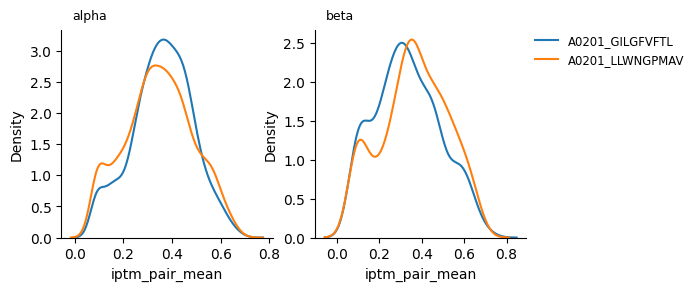

In [22]:
fig, axes = plt.subplots(1,2, figsize=(3*2,2.7))

peptides = ['A0201_GILGFVFTL', 'A0201_LLWNGPMAV']
chains = ['alpha', 'beta']

for cnt, chain in enumerate(chains):
    ax = axes[cnt]
    for peptide in peptides:
        df = pd.read_csv(f'benchmark_LEN/vj060_len000/{peptide}/step0/output_{chain}.csv')[['ID', 'iptm_pair_mean']]
        sns.kdeplot(df, x='iptm_pair_mean', ax=ax, label=peptide)

    sns.despine()
    
    ax.text(0.05, 1.05, f'{chain}', transform=ax.transAxes, fontsize=9)

axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize='small', frameon=False)

In [31]:
peptides = ['A0201_GILGFVFTL', 'A0201_LLWNGPMAV']

for peptide in peptides:
    df1 = pd.read_csv(f'benchmark_LEN/vj060_len000/{peptide}/step2/output_alpha.csv')[['ID', 'iptm_pair_mean']]
    df2 = pd.read_csv(f'benchmark_LEN/vj060_len000/{peptide}/step2/output_beta.csv')[['ID', 'iptm_pair_mean']]
    df = pd.concat([df1, df2])

    s = df['iptm_pair_mean']

    print(peptide)
    print(s.quantile([0.50, 0.90, 0.95, 0.99]))   # several at once


A0201_GILGFVFTL
0.50    0.555700
0.90    0.675840
0.95    0.691210
0.99    0.713308
Name: iptm_pair_mean, dtype: float64
A0201_LLWNGPMAV
0.50    0.57010
0.90    0.64610
0.95    0.66036
0.99    0.68343
Name: iptm_pair_mean, dtype: float64


In [33]:
epitopes = ['A0201_GILGFVFTL', 'A0201_LLWNGPMAV']

for epitope in epitopes:
    df = pd.read_csv('benchmark_LEN/summary.csv')

    df = df[df['epitope'] == epitope]
    print(epitope)
    df_step = df[df['step'] == 1]
    df_step = df_step.groupby(['len'])[['auc', 'auc01']].mean().reset_index()
    print("step 1") 
    print(df_step)
    df_step = df[df['step'] == 2]
    df_step = df_step.groupby(['len'])[['auc', 'auc01']].mean().reset_index()
    print("step 2") 
    print(df_step)


A0201_GILGFVFTL
step 1
   len       auc     auc01
0    0  0.747584  0.596483
1   20  0.773674  0.639181
2   30  0.785259  0.675513
3   60  0.771696  0.634591
step 2
   len       auc     auc01
0    0  0.781870  0.679395
1   20  0.785995  0.683024
2   30  0.791590  0.689799
3   60  0.790623  0.704438
A0201_LLWNGPMAV
step 1
   len       auc     auc01
0    0  0.876495  0.773067
1   20  0.857954  0.791114
2   30  0.868910  0.777773
3   60  0.868340  0.774091
step 2
   len       auc     auc01
0    0  0.852268  0.787569
1   20  0.873595  0.798589
2   30  0.852027  0.782278
3   60  0.858665  0.730026


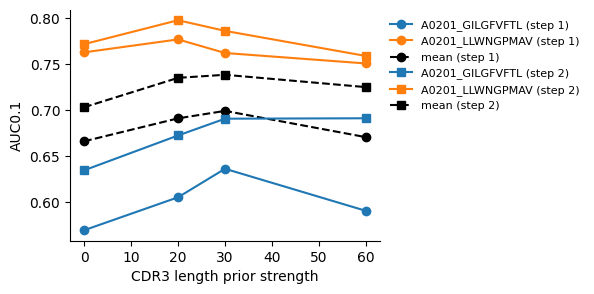

In [10]:
df = pd.read_csv('benchmark_LEN/summary.csv')
#df = pd.read_csv('test/summary_top50.csv')

# marker per step, consistent across the whole figure
step_markers = {1: 'o', 2: 's'}   # add more if you have more steps

fig, ax = plt.subplots(figsize=(4, 3))

# stable color per epitope, shared across steps
epitopes = sorted(df['epitope'].unique())
colors = dict(zip(epitopes, plt.cm.tab10.colors))

for step, marker in step_markers.items():
    d = (df[df['step'] == step]
         .groupby(['len', 'epitope'])[['auc', 'auc01']]
         .mean()
         .reset_index()
         .sort_values('len'))

    # one colored line per epitope
    for epi in epitopes:
        sub = d[d['epitope'] == epi].sort_values('len')
        if sub.empty:
            continue
        ax.plot(sub['len'], sub['auc01'],
                marker=marker, color=colors[epi],
                label=f'{epi} (step {step})')

    # black dashed = mean across epitopes for this step
    mean_line = d.groupby('len')['auc01'].mean().reset_index().sort_values('len')
    ax.plot(mean_line['len'], mean_line['auc01'],
            marker=marker, color='black', linestyle='--',
            label=f'mean (step {step})')

ax.set_xlabel('CDR3 length prior strength')          # <- replace with a meaningful label
ax.set_ylabel('AUC0.1')
ax.legend(fontsize=8, bbox_to_anchor=(1,1), frameon=False)
sns.despine()

In [13]:
df = pd.read_csv('benchmark_LEN/vj060_len030/A0201_LLWNGPMAV/step2/motif_eval.csv')
df

,TRAV,TRAJ,cdr3_TRA,TRBV,TRBJ,cdr3_TRB,model
0,TRAV12-2,TRAJ48,CAEYSGNEKLTF,NaN,NaN,NaN,A0201_LLWNGPMAV
1,TRAV12-2,TRAJ12,CAVMEDKLIF,NaN,NaN,NaN,A0201_LLWNGPMAV
2,TRAV12-2,TRAJ52,CADYYSYGKLTF,NaN,NaN,NaN,A0201_LLWNGPMAV
3,TRAV12-2,TRAJ44,CAENLFETGTASKLTF,NaN,NaN,NaN,A0201_LLWNGPMAV
4,TRAV12-2,TRAJ43,CAVARADMRF,NaN,NaN,NaN,A0201_LLWNGPMAV
...,...,...,...,...,...,...,...
132,NaN,NaN,NaN,TRBV4-2,TRBJ1-5,CASSLERNNTNQPQHF,A0201_LLWNGPMAV
133,NaN,NaN,NaN,TRBV12-3,TRBJ2-7,CASSKGLAYEQYF,A0201_LLWNGPMAV
134,NaN,NaN,NaN,TRBV19,TRBJ2-7,CASAPAANYEQYF,A0201_LLWNGPMAV
135,NaN,NaN,NaN,TRBV25-1,TRBJ1-6,CASSGLGGASPLHF,A0201_LLWNGPMAV


# AUC

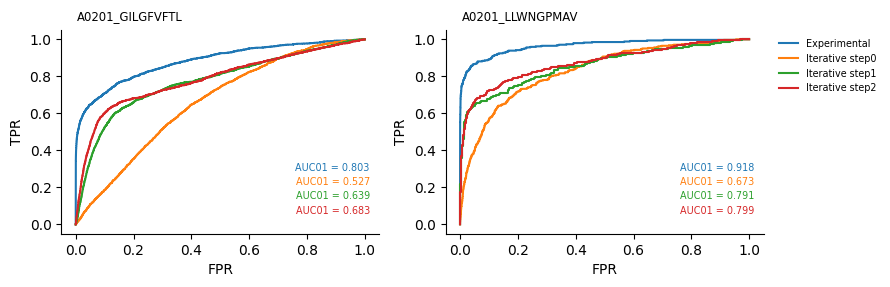

In [57]:
epitopes = ['A0201_GILGFVFTL', 'A0201_LLWNGPMAV']
steps = ['step0', 'step1', 'step2']

fig, axes = plt.subplots(1, len(epitopes), figsize=(9, 3))

for cnt, epitope in enumerate(epitopes):
    ax = axes[cnt]
    ax.text(0.05, 1.1, epitope, transform=ax.transAxes,
            va='top', ha='left', fontsize='small')

    # --- Experimental curve ---
    df = pd.read_csv(
        f'../260512_TEMPO_motif_builder_test/{epitope}/TEMPO_train_exp.csv'
    )
    y_true, y_scores = df['Label'].values, df['score'].values
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    auc01 = roc_auc_score(y_true, y_scores, max_fpr=0.1)
    line, = ax.plot(fpr, tpr, label='Experimental')
    ax.text(0.97, 0.3, f"AUC01 = {auc01:.3f}",
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize='x-small', color=line.get_color())

    # --- One curve per step ---
    for i, s in enumerate(steps):
        if s == 'step0':
            df = pd.read_csv(
                f'TCR_motif_atlas/{epitope}/{s}/validation/validation_pred.csv'
            )
        else:
            df = pd.read_csv(
                f'benchmark_LEN/vj060_len020/{epitope}/{s}/eval/validation_pred.csv'
            )
        y_true, y_scores = df['Label'].values, df['score'].values
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        auc01 = roc_auc_score(y_true, y_scores, max_fpr=0.1)
        line, = ax.plot(fpr, tpr, label=f'Iterative {s}')
        ax.text(0.97, 0.23 - i * 0.07, f"AUC01 = {auc01:.3f}",
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize='x-small', color=line.get_color())

    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')

handles, labels = axes[-1].get_legend_handles_labels()
axes[-1].legend(handles, labels, fontsize='x-small', frameon=False,
                bbox_to_anchor=(1.02, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()




In [14]:
step = 2
df = pd.read_csv(f'bck.TCR_motif_atlas.260706/A0201_GILGFVFTL/step{step}/top_tcrs_beta.csv')
df = df.sort_values(by='iptm_pair_mean', ascending=False)
df

df = df[df['TRBV'] == 'TRBV25-1']
df

,id,TRBV,TRBJ,cdr3_TRB,TRAV,TRAJ,cdr3_TRA,peptide,MHC,species,iptm_pair_mean
42,tcr0087,TRBV25-1,TRBJ1-2,CASSPYGWQGYTF,TRAV38-2/DV8_dummy,TRAJ43,CGGGGGGGGGGF,GILGFVFTL,HLA_A0201,HomoSapiens,0.7219
150,tcr0422,TRBV25-1,TRBJ1-4,CASSGIGTPDEKLFF,TRAV38-2/DV8_dummy,TRAJ43,CGGGGGGGGGGF,GILGFVFTL,HLA_A0201,HomoSapiens,0.7122
159,tcr0458,TRBV25-1,TRBJ2-1,CASSQVEKQFF,TRAV38-2/DV8_dummy,TRAJ43,CGGGGGGGGGGF,GILGFVFTL,HLA_A0201,HomoSapiens,0.7090
436,tcr1124,TRBV25-1,TRBJ1-5,CASILCDSQHF,TRAV38-2/DV8_dummy,TRAJ43,CGGGGGGGGGGF,GILGFVFTL,HLA_A0201,HomoSapiens,0.7073
93,tcr0228,TRBV25-1,TRBJ2-1,CASQSATGNEQFF,TRAV38-2/DV8_dummy,TRAJ43,CGGGGGGGGGGF,GILGFVFTL,HLA_A0201,HomoSapiens,0.7061
...,...,...,...,...,...,...,...,...,...,...,...
389,tcr1007,TRBV25-1,TRBJ1-5,CASSLSNSNQPQHF,TRAV38-2/DV8_dummy,TRAJ43,CGGGGGGGGGGF,GILGFVFTL,HLA_A0201,HomoSapiens,0.6512
241,tcr0665,TRBV25-1,TRBJ1-5,CASSRIGGGSQPQHF,TRAV38-2/DV8_dummy,TRAJ43,CGGGGGGGGGGF,GILGFVFTL,HLA_A0201,HomoSapiens,0.6512
304,tcr0794,TRBV25-1,TRBJ2-7,CASSSVGSDADEQYF,TRAV38-2/DV8_dummy,TRAJ43,CGGGGGGGGGGF,GILGFVFTL,HLA_A0201,HomoSapiens,0.6508
429,tcr1101,TRBV25-1,TRBJ1-2,CASSPGGAGGYTF,TRAV38-2/DV8_dummy,TRAJ43,CGGGGGGGGGGF,GILGFVFTL,HLA_A0201,HomoSapiens,0.6506
